# Football Ball Detection Fix

**Problem:** Ball is ~11px at 640 resolution — too small to detect reliably.

**Solution:** Train at 1280 resolution (ball becomes ~22px).

**Time:** ~1 hour on A100 with batch=8

---

**Run cells in order. Do not skip cells.**

## 1. Setup

In [1]:
!pip install ultralytics --quiet
!pip install roboflow --quiet
print("✅ Dependencies installed")

✅ Dependencies installed


In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted


## 2. Download Dataset

In [3]:
# Delete old broken folder
!rm -rf /content/football-players-detection-1
!rm -rf /content/football-players-detection*
print("✅ Old folders deleted")

✅ Old folders deleted


In [4]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="rK668FEC7IF3N3gkhZYs")
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(1)
dataset = version.download("yolov5")

# Store the path
DATASET_PATH = dataset.location
print(f"\n✅ Dataset downloaded to: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to football-players-detection-1 in yolov5pytorch:: 100%|██████████| 1338/1338 [00:00<00:00, 3700.09it/s]


✅ Dataset downloaded to: /content/football-players-detection-1


In [5]:
# Verify folder structure is correct
import os

def find_data_yaml(start_path):
    """Find data.yaml and verify train folder exists at same level"""
    for root, dirs, files in os.walk(start_path):
        if 'data.yaml' in files:
            data_yaml = os.path.join(root, 'data.yaml')
            train_dir = os.path.join(root, 'train')
            if os.path.exists(train_dir):
                return root
    return None

# Find correct path
correct_path = find_data_yaml(DATASET_PATH)

if correct_path:
    DATASET_PATH = correct_path
    print(f"✅ Found valid dataset at: {DATASET_PATH}")
else:
    print(f"❌ Could not find valid dataset structure")

# Show structure
print(f"\n📁 Contents of {DATASET_PATH}:")
for item in os.listdir(DATASET_PATH):
    print(f"   {'📁' if os.path.isdir(os.path.join(DATASET_PATH, item)) else '📄'} {item}")

✅ Found valid dataset at: /content/football-players-detection-1

📁 Contents of /content/football-players-detection-1:
   📁 train
   📁 valid
   📄 README.dataset.txt
   📄 data.yaml
   📄 README.roboflow.txt
   📁 test


## 3. Audit Dataset (Optional)

In [6]:
import os, glob
from collections import Counter
from PIL import Image
import yaml
import numpy as np
import pandas as pd

def analyse_yolo_dataset(root, ball_name="ball"):
    """Analyse YOLO dataset to check ball statistics."""
    data_yaml = os.path.join(root, "data.yaml")
    if not os.path.exists(data_yaml):
        print(f"❌ data.yaml not found at {data_yaml}")
        return None

    with open(data_yaml, "r") as f:
        d = yaml.safe_load(f)

    names = d.get("names")
    if isinstance(names, dict):
        names = [names[i] for i in range(len(names))]

    print(f"Classes: {names}")

    if ball_name not in names:
        print(f"❌ '{ball_name}' not found in classes")
        return None

    ball_id = names.index(ball_name)
    print(f"Ball class ID: {ball_id}\n")

    rows = []

    for split, folder in {"train": "train", "valid": "valid", "test": "test"}.items():
        labels_dir = os.path.join(root, folder, "labels")
        images_dir = os.path.join(root, folder, "images")

        if not os.path.exists(labels_dir):
            continue

        label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
        per_class = Counter()
        ball_boxes_px = []

        for lf in label_files:
            stem = os.path.splitext(os.path.basename(lf))[0]
            img_path = None
            for ext in (".jpg", ".jpeg", ".png"):
                p = os.path.join(images_dir, stem + ext)
                if os.path.exists(p):
                    img_path = p
                    break
            if not img_path:
                continue

            w_img, h_img = Image.open(img_path).size

            with open(lf, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls = int(float(parts[0]))
                    bw = float(parts[3]) * w_img
                    bh = float(parts[4]) * h_img
                    per_class[cls] += 1
                    if cls == ball_id:
                        ball_boxes_px.append((bw, bh))

        rows.append({
            "split": split,
            "images": len(glob.glob(os.path.join(images_dir, "*"))),
            "ball_instances": per_class[ball_id],
            "ball_w_median": round(np.median([b[0] for b in ball_boxes_px]), 1) if ball_boxes_px else 0,
            "ball_h_median": round(np.median([b[1] for b in ball_boxes_px]), 1) if ball_boxes_px else 0,
        })
        print(f"✅ {split}: {len(label_files)} labels, {per_class[ball_id]} ball instances")

    return pd.DataFrame(rows) if rows else None

# Run audit
print("="*50)
print("DATASET AUDIT")
print("="*50)
df = analyse_yolo_dataset(DATASET_PATH)

if df is not None and len(df) > 0:
    print("\n")
    display(df)

    # Interpretation
    train_row = df[df['split'] == 'train'].iloc[0]
    ball_w = train_row['ball_w_median']
    ball_h = train_row['ball_h_median']

    print(f"\n📊 Ball median size: {ball_w} x {ball_h} pixels")
    if ball_w < 15 or ball_h < 15:
        print(f"⚠️  Ball is SMALL at 640px")
        print(f"✅ Training at 1280 will double size to ~{ball_w*2}x{ball_h*2}px")

DATASET AUDIT
Classes: ['ball', 'goalkeeper', 'player', 'referee']
Ball class ID: 0

✅ train: 612 labels, 519 ball instances
✅ valid: 38 labels, 35 ball instances
✅ test: 13 labels, 11 ball instances




,split,images,ball_instances,ball_w_median,ball_h_median
0,train,612,519,11.0,11.9
1,valid,38,35,10.8,11.2
2,test,13,11,11.5,12.1



📊 Ball median size: 11.0 x 11.9 pixels
⚠️  Ball is SMALL at 640px
✅ Training at 1280 will double size to ~22.0x23.8px


## 4. Train Model

| Parameter | Original | New | Why |
|-----------|----------|-----|-----|
| `imgsz` | 640 | **1280** | Ball becomes ~22px instead of ~11px |
| `epochs` | 100 | **200** | More time to learn small objects |
| `close_mosaic` | - | **50** | Stops mosaic shrinking ball in final epochs |
| `batch` | 16 | **8** | A100 optimised for 1280px |

In [7]:
# Fix the data.yaml paths
import yaml

data_yaml_path = f"{DATASET_PATH}/data.yaml"

with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Show current paths
print("Current paths in data.yaml:")
print(f"  train: {data.get('train')}")
print(f"  val: {data.get('val')}")
print(f"  test: {data.get('test')}")

# Fix to use simple relative paths
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

with open(data_yaml_path, 'w') as f:
    yaml.dump(data, f)

print("\n✅ Fixed paths:")
print(f"  train: {data['train']}")
print(f"  val: {data['val']}")
print(f"  test: {data['test']}")

Current paths in data.yaml:
  train: football-players-detection-1/train/images
  val: football-players-detection-1/valid/images
  test: ../test/images

✅ Fixed paths:
  train: train/images
  val: valid/images
  test: test/images


In [8]:
!yolo task=detect mode=train model=yolov5x.pt data={DATASET_PATH}/data.yaml epochs=200 imgsz=1280 batch=8 close_mosaic=50

PRO TIP 💡 Replace 'model=yolov5x.pt' with new 'model=yolov5xu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Ultralytics 8.3.244 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=50, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football-players-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_

### ⚠️ If memory error, run this instead:

In [9]:
# ONLY RUN IF ABOVE FAILS WITH MEMORY ERROR
# !yolo task=detect mode=train model=yolov5x.pt data={DATASET_PATH}/data.yaml epochs=200 imgsz=1280 batch=4 close_mosaic=50

## 5. Check Results

In [10]:
import os

# Find latest training run
runs_dir = "runs/detect"
runs = sorted([d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d))]) if os.path.exists(runs_dir) else []
LATEST_RUN = runs[-1] if runs else "train"

print(f"Training runs: {runs}")
print(f"Using: {LATEST_RUN}")

Training runs: ['train', 'train2', 'train3', 'train4', 'train5', 'train6']
Using: train6


📈 Training curves:


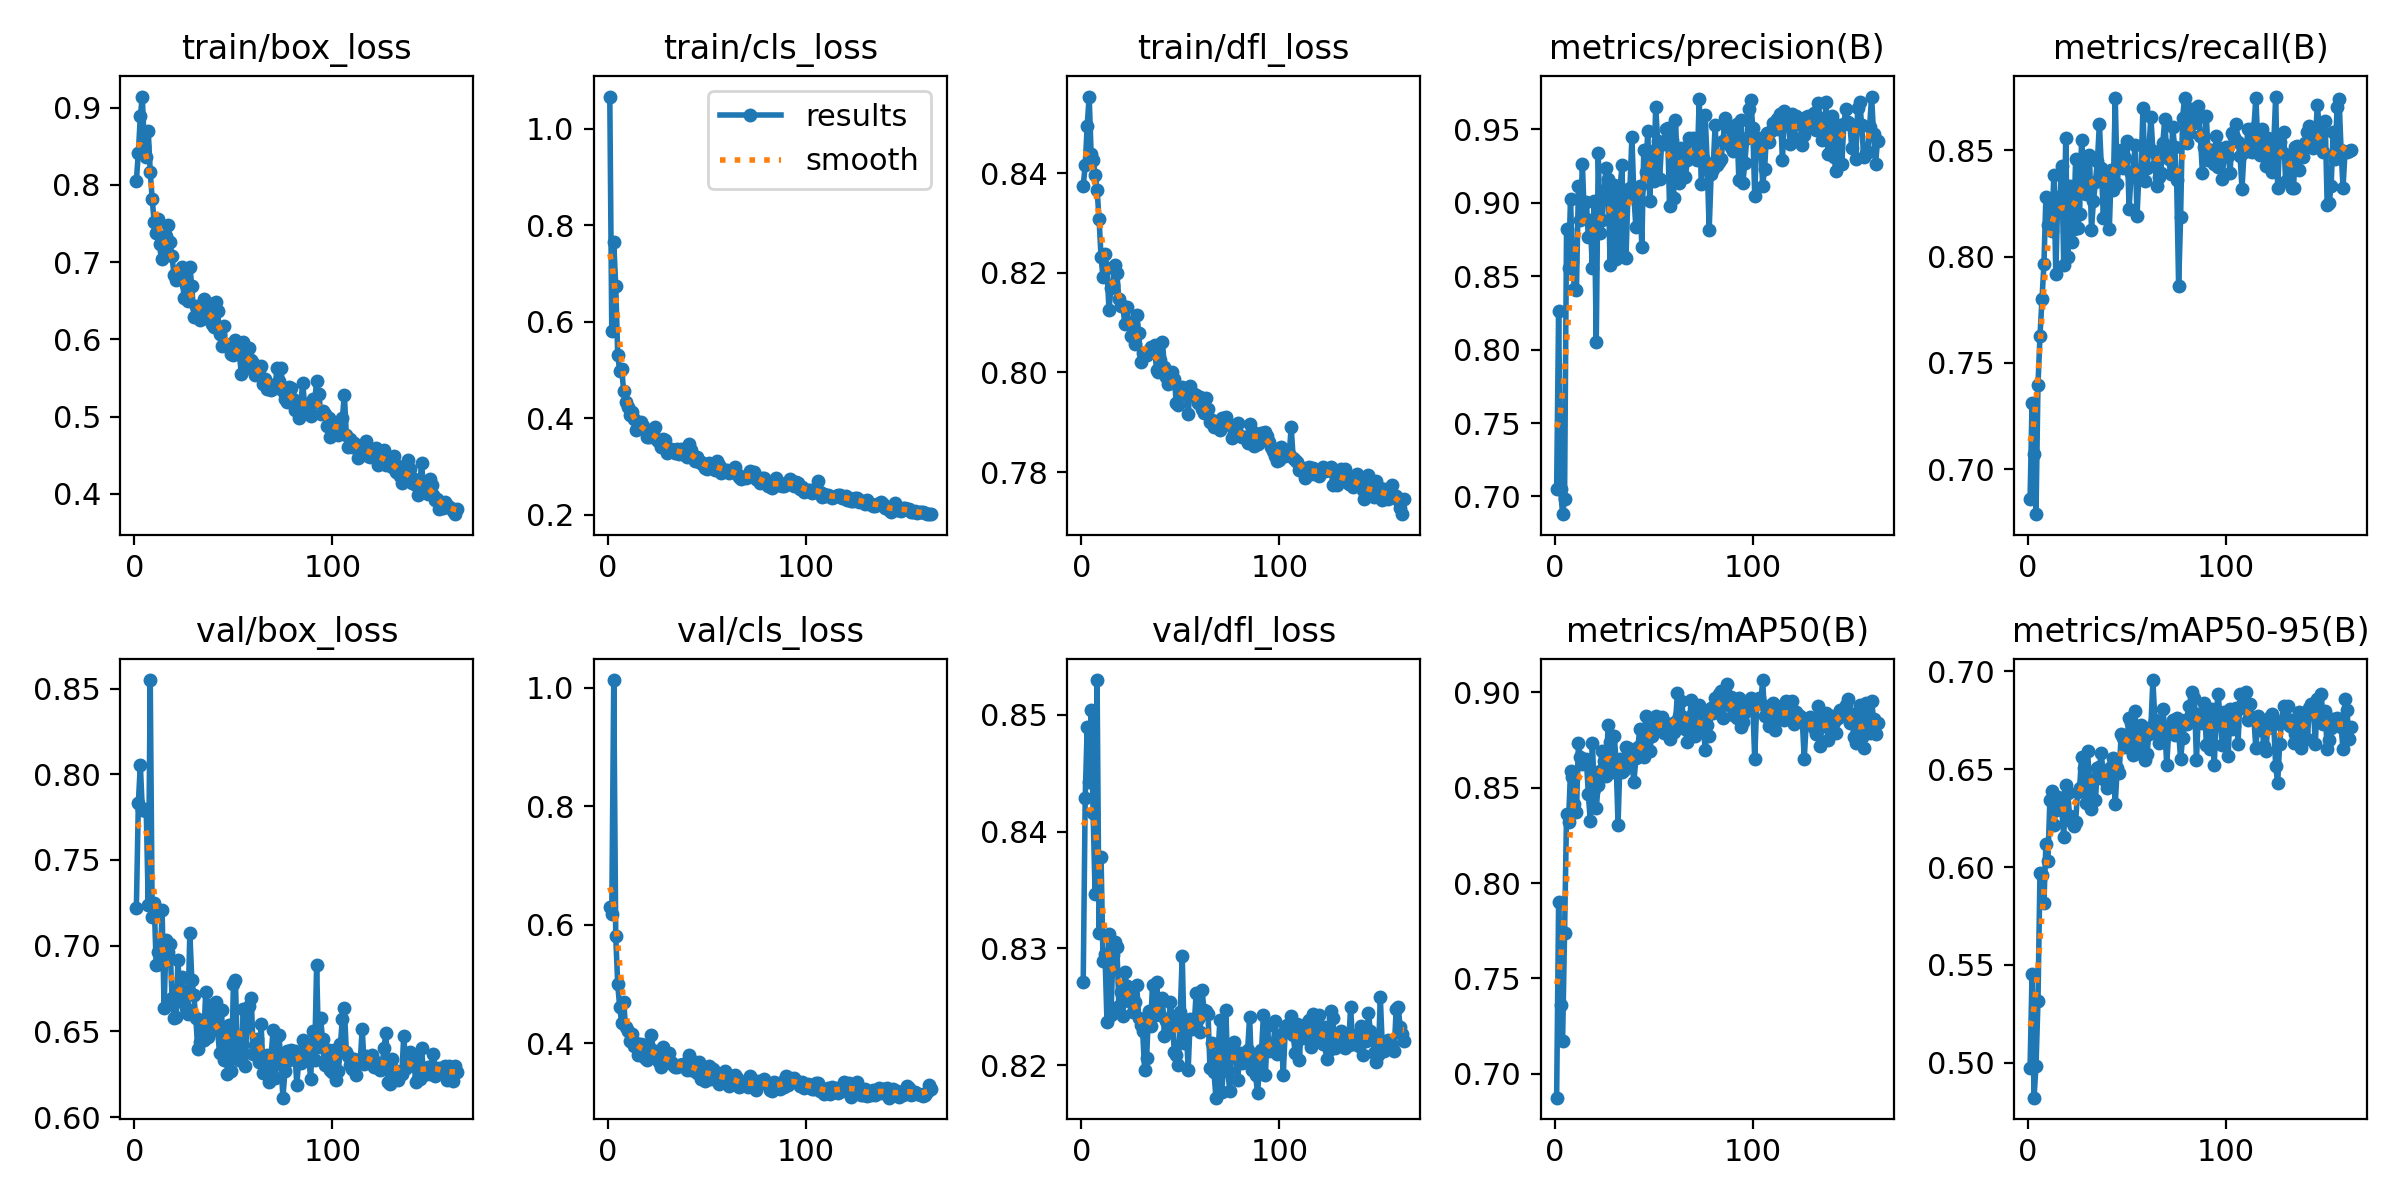

In [11]:
from IPython.display import Image, display

results_img = f"runs/detect/{LATEST_RUN}/results.png"
if os.path.exists(results_img):
    print("📈 Training curves:")
    display(Image(results_img, width=800))
else:
    print(f"Results not found at {results_img}")

## 6. Save Model

In [12]:
import shutil

# Paths
DEST = "/content/drive/MyDrive/Colab Notebooks/football_analysis_project/yolov5"
SRC_BEST = f"runs/detect/{LATEST_RUN}/weights/best.pt"
SRC_LAST = f"runs/detect/{LATEST_RUN}/weights/last.pt"

# Create destination
os.makedirs(DEST, exist_ok=True)

# Copy files
if os.path.exists(SRC_BEST):
    shutil.copy(SRC_BEST, f"{DEST}/best.pt")
    shutil.copy(SRC_LAST, f"{DEST}/last.pt")
    print("="*50)
    print("✅ MODEL SAVED TO GOOGLE DRIVE")
    print("="*50)
    print(f"Location: {DEST}")
    !ls -lh "{DEST}"
else:
    print(f"❌ Model not found at {SRC_BEST}")

✅ MODEL SAVED TO GOOGLE DRIVE
Location: /content/drive/MyDrive/Colab Notebooks/football_analysis_project/yolov5
total 373M
-rw------- 1 root root 187M Dec 31 20:21 best.pt
-rw------- 1 root root 187M Dec 31 20:21 last.pt


In [13]:
# Download to computer
from google.colab import files

if os.path.exists(SRC_BEST):
    print("📥 Downloading best.pt...")
    files.download(SRC_BEST)

📥 Downloading best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>